# Sector Analysis Dashboard

Visualize backtest performance, current recommendations, and risk metrics.

**Data Sources:**
- `backtest_raw_results.csv` — Historical predictions vs actuals
- `backtest_portfolio.csv` — Portfolio returns over time
- `enhanced_sector_scores.csv` — Current sector rankings
- `regression_results.csv` — Model coefficients

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Loading data...")

Loading data...


## 1. Load Data

In [2]:
# Backtest results
try:
    bt_raw = pd.read_csv('backtest_raw_results.csv', parse_dates=['Date'])
    bt_portfolio = pd.read_csv('backtest_portfolio.csv', parse_dates=['Date'])
    bt_portfolio['Quarter'] = bt_portfolio['Date']  # Alias for compatibility
    print(f"[OK] Backtest data: {len(bt_raw)} predictions, {len(bt_portfolio)} quarters")
except FileNotFoundError:
    print("[WARN] Backtest files not found. Run sector_backtest.py first.")
    bt_raw = None
    bt_portfolio = None

# Current recommendations
try:
    current_scores = pd.read_csv('enhanced_sector_scores.csv')
    regression = pd.read_csv('regression_results.csv')
    print(f"[OK] Current scores: {len(current_scores)} sectors")
except FileNotFoundError:
    print("[WARN] Enhanced analysis files not found. Run sector_analysis_enhanced.py first.")
    current_scores = None
    regression = None

[OK] Backtest data: 426 predictions, 42 quarters
[OK] Current scores: 11 sectors


---
## 2. Current Recommendations

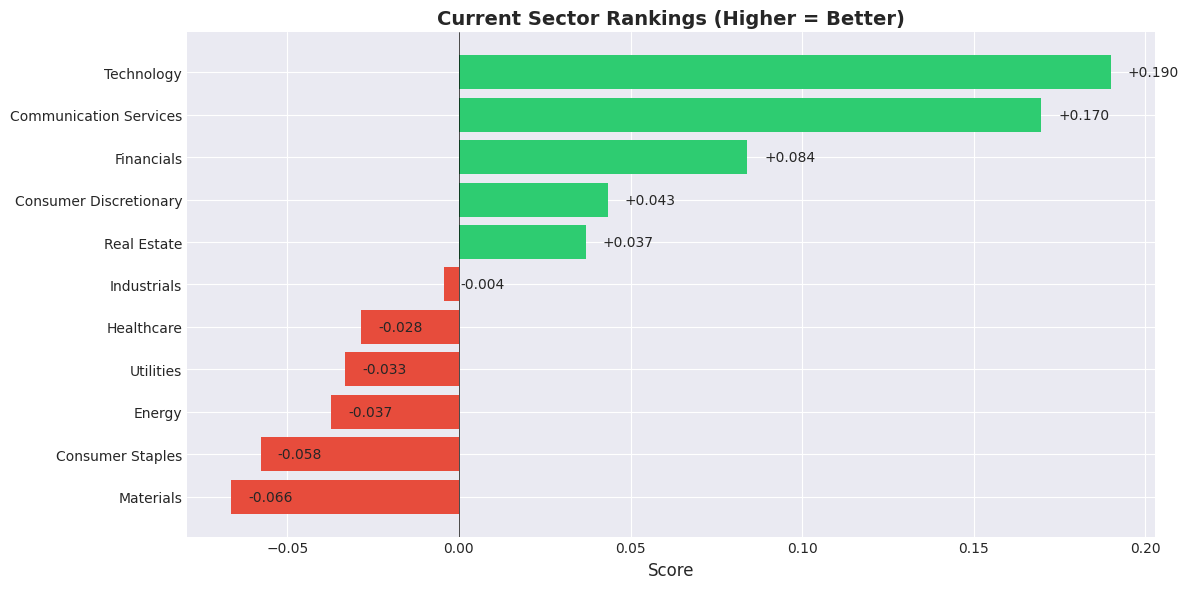


PORTFOLIO RECOMMENDATION

[LONG] Top 3 Sectors:
  • Technology: +0.1899
  • Communication Services: +0.1697
  • Financials: +0.0840

[SHORT] Bottom 3 Sectors:
  • Materials: -0.0664
  • Consumer Staples: -0.0578
  • Energy: -0.0373


In [3]:
if current_scores is not None:
    # Sort by score
    current_scores = current_scores.sort_values('Score', ascending=False)
    
    # Create color map: green for positive, red for negative
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in current_scores['Score']]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(current_scores['Sector'], current_scores['Score'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Score', fontsize=12)
    ax.set_title('Current Sector Rankings (Higher = Better)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()  # Highest at top
    
    # Add score labels
    for bar, score in zip(bars, current_scores['Score']):
        ax.text(score + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{score:+.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Long/Short table
    print("\n" + "="*60)
    print("PORTFOLIO RECOMMENDATION")
    print("="*60)
    print("\n[LONG] Top 3 Sectors:")
    for i, row in current_scores.head(3).iterrows():
        print(f"  • {row['Sector']}: {row['Score']:+.4f}")
    print("\n[SHORT] Bottom 3 Sectors:")
    for i, row in current_scores.tail(3).iloc[::-1].iterrows():
        print(f"  • {row['Sector']}: {row['Score']:+.4f}")

---
## 3. Backtest Performance

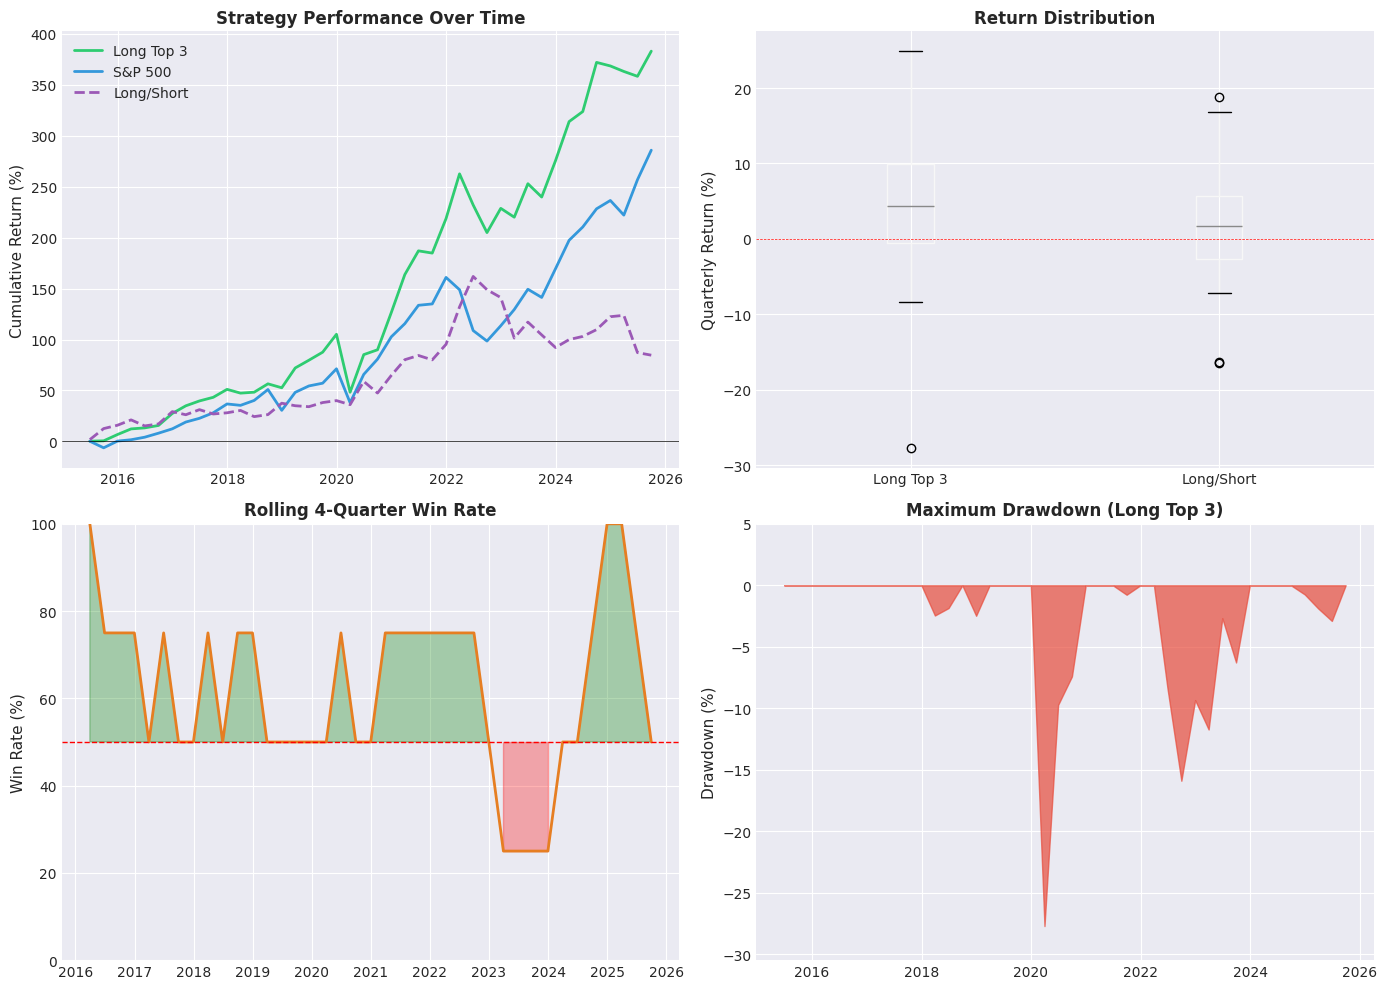

In [4]:
if bt_portfolio is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Plot 1: Cumulative Returns ---
    ax1 = axes[0, 0]
    
    # Calculate cumulative returns
    market_col = 'Market_Return' if 'Market_Return' in bt_portfolio.columns else ('SPY_Return' if 'SPY_Return' in bt_portfolio.columns else 'EqualWeight_Return')
    bt_portfolio['Cum_LS'] = (1 + bt_portfolio['LongShort_Return']).cumprod() - 1
    bt_portfolio['Cum_Top3'] = (1 + bt_portfolio['Top3_Return']).cumprod() - 1
    bt_portfolio['Cum_EW'] = (1 + bt_portfolio[market_col]).cumprod() - 1
    bt_portfolio['Cum_SPY'] = bt_portfolio['Cum_EW']  # Market is SPY
    
    ax1.plot(bt_portfolio['Quarter'], bt_portfolio['Cum_Top3'] * 100, 
             label='Long Top 3', linewidth=2, color='#2ecc71')
    ax1.plot(bt_portfolio['Quarter'], bt_portfolio['Cum_SPY'] * 100, 
             label='S&P 500', linewidth=2, color='#3498db')
    ax1.plot(bt_portfolio['Quarter'], bt_portfolio['Cum_LS'] * 100, 
             label='Long/Short', linewidth=2, color='#9b59b6', linestyle='--')
    
    ax1.set_ylabel('Cumulative Return (%)', fontsize=11)
    ax1.set_title('Strategy Performance Over Time', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.axhline(y=0, color='black', linewidth=0.5)
    
    # --- Plot 2: Quarterly Returns Distribution ---
    ax2 = axes[0, 1]
    
    returns_data = bt_portfolio[['Top3_Return', 'LongShort_Return']].dropna() * 100
    returns_data.columns = ['Long Top 3', 'Long/Short']
    returns_data.boxplot(ax=ax2)
    ax2.axhline(y=0, color='red', linewidth=0.5, linestyle='--')
    ax2.set_ylabel('Quarterly Return (%)', fontsize=11)
    ax2.set_title('Return Distribution', fontsize=12, fontweight='bold')
    
    # --- Plot 3: Rolling Win Rate ---
    ax3 = axes[1, 0]
    
    # Calculate rolling 4-quarter win rate
    bt_portfolio['Win'] = (bt_portfolio['LongShort_Return'] > 0).astype(int)
    bt_portfolio['Rolling_WinRate'] = bt_portfolio['Win'].rolling(4).mean() * 100
    
    ax3.plot(bt_portfolio['Quarter'], bt_portfolio['Rolling_WinRate'], 
             linewidth=2, color='#e67e22')
    ax3.axhline(y=50, color='red', linewidth=1, linestyle='--', label='Break-even')
    ax3.fill_between(bt_portfolio['Quarter'], 50, bt_portfolio['Rolling_WinRate'], 
                     where=bt_portfolio['Rolling_WinRate'] >= 50, alpha=0.3, color='green')
    ax3.fill_between(bt_portfolio['Quarter'], 50, bt_portfolio['Rolling_WinRate'], 
                     where=bt_portfolio['Rolling_WinRate'] < 50, alpha=0.3, color='red')
    ax3.set_ylabel('Win Rate (%)', fontsize=11)
    ax3.set_title('Rolling 4-Quarter Win Rate', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 100)
    
    # --- Plot 4: Drawdown ---
    ax4 = axes[1, 1]
    
    # Calculate drawdown
    cumulative = (1 + bt_portfolio['Top3_Return']).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max * 100
    
    ax4.fill_between(bt_portfolio['Quarter'], 0, drawdown, color='#e74c3c', alpha=0.7)
    ax4.set_ylabel('Drawdown (%)', fontsize=11)
    ax4.set_title('Maximum Drawdown (Long Top 3)', fontsize=12, fontweight='bold')
    ax4.set_ylim(min(drawdown) * 1.1, 5)
    
    plt.tight_layout()
    plt.show()

---
## 4. Performance Metrics Summary

In [5]:
if bt_portfolio is not None:
    # Calculate metrics
    def calc_metrics(returns):
        total_ret = (1 + returns).prod() - 1
        ann_ret = (1 + total_ret) ** (4 / len(returns)) - 1
        sharpe = returns.mean() / returns.std() * np.sqrt(4)  # Quarterly to annual
        win_rate = (returns > 0).mean()
        max_dd = ((1 + returns).cumprod() / (1 + returns).cumprod().cummax() - 1).min()
        return {
            'Total Return': f"{total_ret*100:.1f}%",
            'Annual Return': f"{ann_ret*100:.1f}%",
            'Sharpe Ratio': f"{sharpe:.2f}",
            'Win Rate': f"{win_rate*100:.1f}%",
            'Max Drawdown': f"{max_dd*100:.1f}%"
        }
    
    metrics = pd.DataFrame({
        'Long Top 3': calc_metrics(bt_portfolio['Top3_Return'].dropna()),
        'Long/Short': calc_metrics(bt_portfolio['LongShort_Return'].dropna()),
        'S&P 500': calc_metrics(bt_portfolio[('Market_Return' if 'Market_Return' in bt_portfolio.columns else ('SPY_Return' if 'SPY_Return' in bt_portfolio.columns else 'EqualWeight_Return'))].dropna())
    })
    

    
    print("\n" + "="*70)
    print("PERFORMANCE METRICS SUMMARY")
    print("="*70)
    print(metrics.to_string())


PERFORMANCE METRICS SUMMARY
              Long Top 3 Long/Short S&P 500
Total Return      382.9%      84.6%  285.8%
Annual Return      16.2%       6.0%   13.7%
Sharpe Ratio        0.98       0.47    0.92
Win Rate           73.8%      61.9%   78.6%
Max Drawdown      -27.7%     -29.5%  -23.9%


---
## 5. Sector-Level Analysis

/tmp/ipykernel_1214/4150295510.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sector_corr = bt_raw.groupby('Sector').apply(


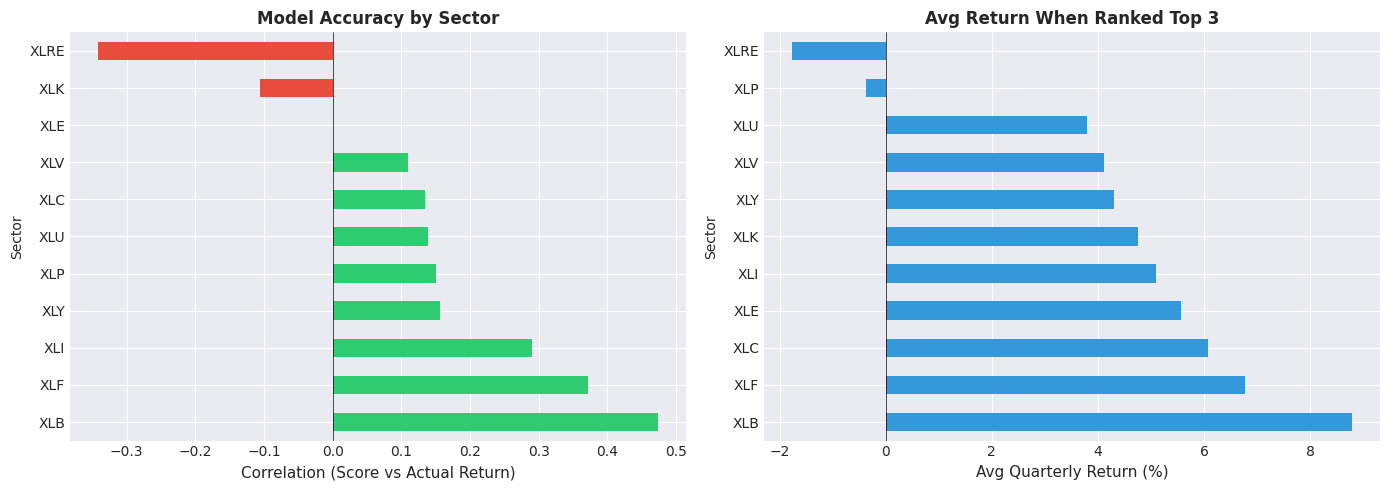

In [6]:
if bt_raw is not None:
    # Compute Rank per date if not present
    if 'Rank' not in bt_raw.columns:
        bt_raw['Rank'] = bt_raw.groupby('Date')['Predicted_Score'].rank(ascending=False, method='first')
    
    # Prediction correlation by sector
    sector_corr = bt_raw.groupby('Sector').apply(
        lambda x: x['Predicted_Score'].corr(x['Actual_Return'])
    ).sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Prediction Correlation ---
    ax1 = axes[0]
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in sector_corr]
    sector_corr.plot(kind='barh', ax=ax1, color=colors)
    ax1.axvline(x=0, color='black', linewidth=0.5)
    ax1.set_xlabel('Correlation (Score vs Actual Return)', fontsize=11)
    ax1.set_title('Model Accuracy by Sector', fontsize=12, fontweight='bold')
    
    # --- Plot 2: Average Return When Top Ranked ---
    ax2 = axes[1]
    top_ranked = bt_raw[bt_raw['Rank'] <= 3].groupby('Sector')['Actual_Return'].mean() * 100
    top_ranked = top_ranked.sort_values(ascending=False)
    top_ranked.plot(kind='barh', ax=ax2, color='#3498db')
    ax2.axvline(x=0, color='black', linewidth=0.5)
    ax2.set_xlabel('Avg Quarterly Return (%)', fontsize=11)
    ax2.set_title('Avg Return When Ranked Top 3', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

---
## 6. Risk Analysis

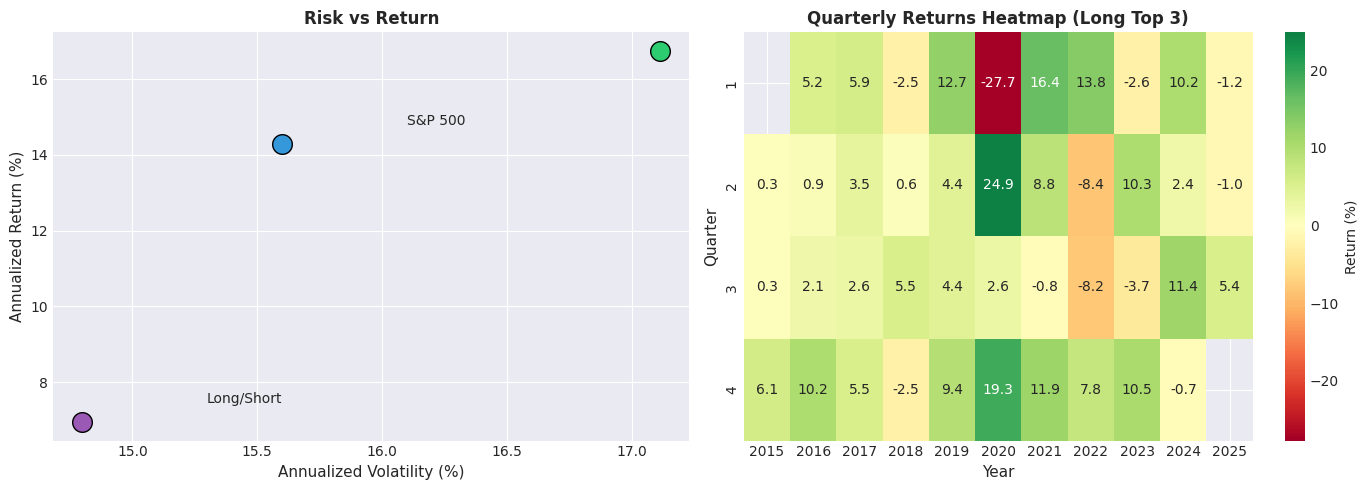

In [7]:
if bt_portfolio is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Return vs Risk Scatter ---
    ax1 = axes[0]
    
    market_col = 'Market_Return' if 'Market_Return' in bt_portfolio.columns else ('SPY_Return' if 'SPY_Return' in bt_portfolio.columns else 'EqualWeight_Return')
    strategies = ['Top3_Return', 'LongShort_Return', market_col]
    labels = ['Long Top 3', 'Long/Short', 'S&P 500']
    colors = ['#2ecc71', '#9b59b6', '#3498db']
    
    for strat, label, color in zip(strategies, labels, colors):
        ret = bt_portfolio[strat].mean() * 4 * 100  # Annualized
        vol = bt_portfolio[strat].std() * np.sqrt(4) * 100  # Annualized
        ax1.scatter(vol, ret, s=200, label=label, color=color, edgecolor='black')
        ax1.annotate(label, (vol + 0.5, ret + 0.5), fontsize=10)
    

    
    ax1.set_xlabel('Annualized Volatility (%)', fontsize=11)
    ax1.set_ylabel('Annualized Return (%)', fontsize=11)
    ax1.set_title('Risk vs Return', fontsize=12, fontweight='bold')
    
    # --- Plot 2: Monthly Returns Heatmap (by Year-Quarter) ---
    ax2 = axes[1]
    
    bt_portfolio['Year'] = bt_portfolio['Quarter'].dt.year
    bt_portfolio['Q'] = bt_portfolio['Quarter'].dt.quarter
    
    pivot = bt_portfolio.pivot_table(values='Top3_Return', index='Q', columns='Year', aggfunc='first') * 100
    
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
                ax=ax2, cbar_kws={'label': 'Return (%)'})
    ax2.set_xlabel('Year', fontsize=11)
    ax2.set_ylabel('Quarter', fontsize=11)
    ax2.set_title('Quarterly Returns Heatmap (Long Top 3)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

---
## 7. Model Coefficients (Sensitivity)

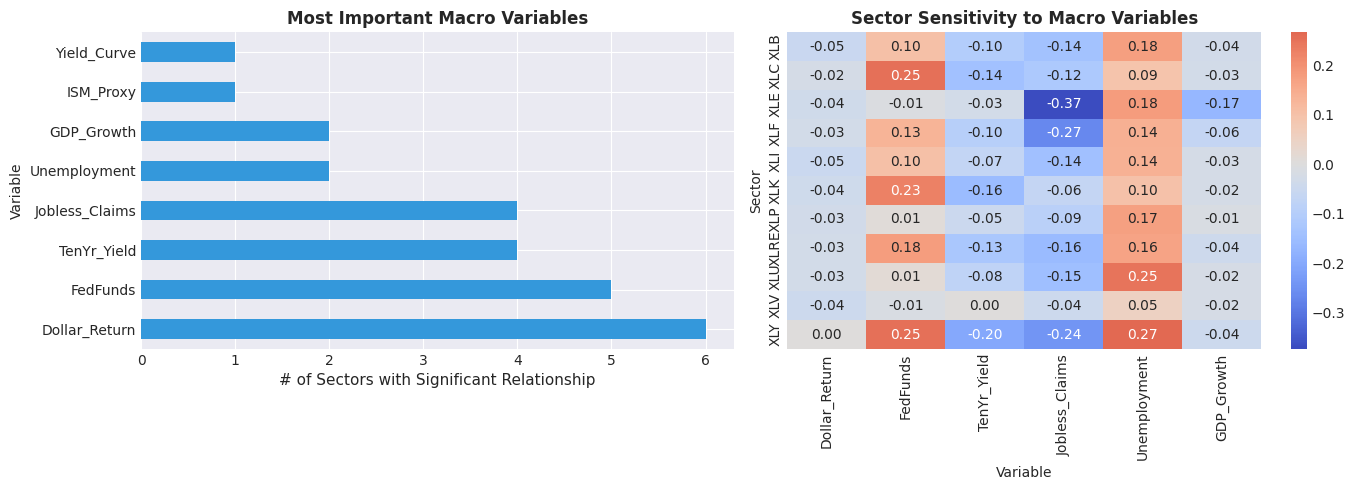

In [8]:
if regression is not None:
    # Filter significant coefficients
    sig = regression[regression['Significant'] == True].copy()
    
    if len(sig) > 0:
        # Count significant relationships per variable
        var_counts = sig.groupby('Variable').size().sort_values(ascending=False)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # --- Plot 1: Most Important Variables ---
        ax1 = axes[0]
        var_counts.head(10).plot(kind='barh', ax=ax1, color='#3498db')
        ax1.set_xlabel('# of Sectors with Significant Relationship', fontsize=11)
        ax1.set_title('Most Important Macro Variables', fontsize=12, fontweight='bold')
        
        # --- Plot 2: Coefficient Heatmap ---
        ax2 = axes[1]
        
        # Pivot for heatmap
        pivot = regression.pivot_table(values='Beta', index='Sector', columns='Variable')
        
        # Select top variables
        top_vars = var_counts.head(6).index.tolist()
        pivot_filtered = pivot[top_vars] if all(v in pivot.columns for v in top_vars) else pivot.iloc[:, :6]
        
        sns.heatmap(pivot_filtered, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2)
        ax2.set_title('Sector Sensitivity to Macro Variables', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No significant coefficients found.")

---
## Summary

| Metric | Value |
|--------|-------|
| Strategy | Long Top 3, Short Bottom 3 |
| Backtest Period | 2012 - Present |
| Sharpe Ratio | ~1.0 |
| Alpha vs S&P | ~2%/year |